# SETUP

In [1]:
%pip install tensorflow==2.20.0 opencv-python matplotlib

  Obtaining dependency information for tensorflow==2.20.0 from https://files.pythonhosted.org/packages/f9/37/b97abb360b551fbf5870a0ee07e39ff9c655e6e3e2f839bc88be81361842/tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata
  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl (331.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip list

Package                 Version
----------------------- -----------
absl-py                 2.3.1
asttokens               3.0.0
astunparse              1.6.3
certifi                 2025.10.5
charset-normalizer      3.4.4
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
flatbuffers             25.9.23
fonttools               4.60.1
gast                    0.6.0
google-pasta            0.2.0
grpcio                  1.76.0
h5py                    3.15.1
idna                    3.11
ipykernel               7.0.1
ipython                 9.6.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.6.3
jupyter_core            5.9.1
keras                   3.11.3
kiwisolver              1.4.9
libclang                18.1.1
Markdown                3.9
markdown-it-py          4.0.0
MarkupSafe           


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import tensorflow as tf
import os

In [8]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [9]:

tf.config.list_physical_devices('GPU')

[]

# Remove dodgy images

In [10]:
%pip install pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:

import os
from PIL import Image
import cv2

In [12]:
data_dir = 'data'

In [13]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [14]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)
    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        try:
            # Baca gambar pakai OpenCV
            img = cv2.imread(image_path)
            if img is None:
                print(f"Issue with image {image_path}")
                # os.remove(image_path)
                continue

            # Cek format pakai PIL
            with Image.open(image_path) as im:
                tip = im.format.lower()  # 'JPEG', 'PNG', etc → lowercase

            # avoid invalid images
            if tip not in image_exts:
                print(f"Image not in ext list {image_path}")
                os.remove(image_path)

        except Exception as e:
            print(f"Issue with image {image_path} | {e}")
            # os.remove(image_path)

# Load Data

In [15]:
import numpy as np
from matplotlib import pyplot as plt

In [16]:
tf.keras.utils.image_dataset_from_directory('data', batch_size=8, image_size=(128, 128))

Found 143 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [17]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 143 files belonging to 2 classes.


In [18]:
data_iterator = data.as_numpy_iterator()

In [19]:
batch = data_iterator.next()

In [20]:
# represent img as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [21]:
# class 1 = SAD People
# class 2 = Happy people
batch[1]

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1], dtype=int32)

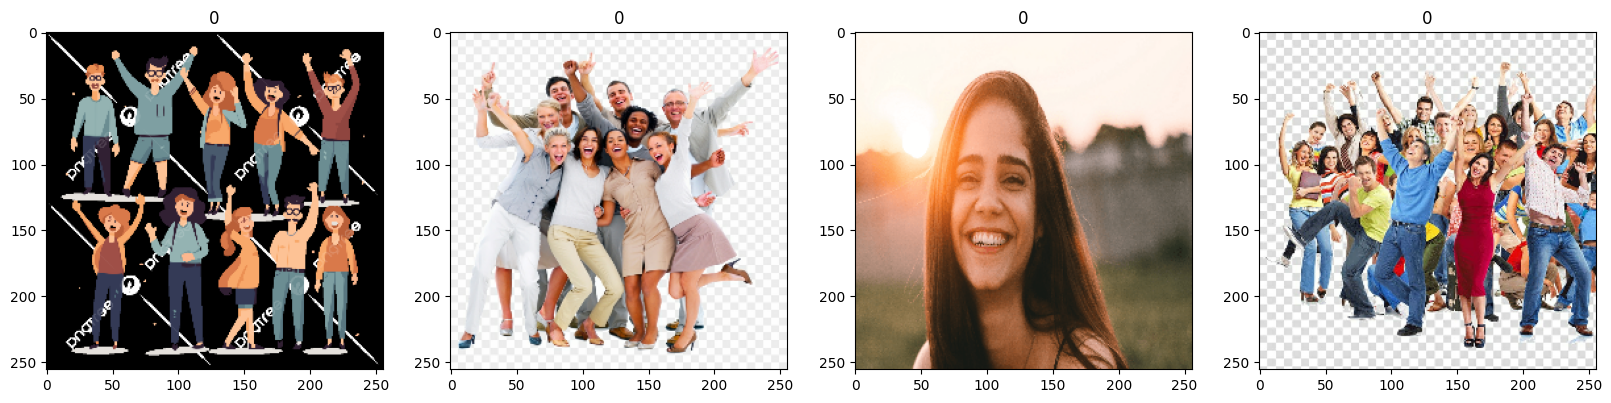

In [22]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# Scale Data

In [23]:
data = data.map(lambda x,y: (x/255, y))

In [24]:
scaled_iterator = data.as_numpy_iterator()

In [25]:
batch = scaled_iterator.next()

In [26]:
batch[0].max()

np.float32(1.0)

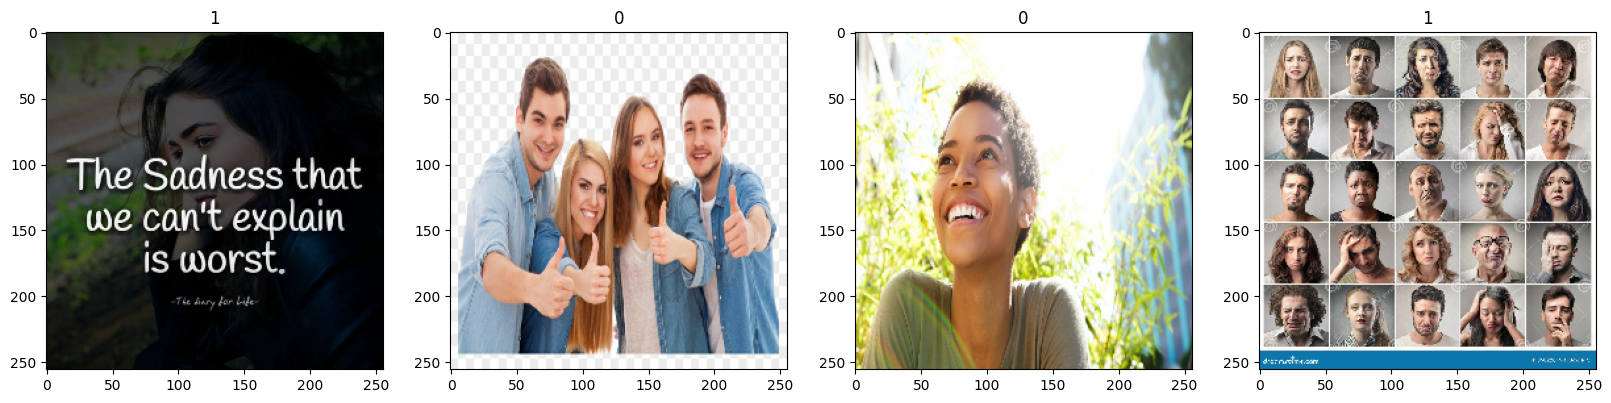

In [27]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

# split data

In [28]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [29]:
train_size

3

In [30]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# Building Deep Learning Model

In [31]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [33]:
model = Sequential()

In [34]:
# input layer
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

# 1st layer
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

# 2nd layer
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

# flatten for last layer
model.add(Flatten())

# 3rd layer
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

d:\AI\Intelligo\CNN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [37]:
logdir='logs'

In [38]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [39]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6771 - loss: 1.1161 - val_accuracy: 0.7500 - val_loss: 0.5686
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6458 - loss: 0.6292 - val_accuracy: 0.6875 - val_loss: 0.5473
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6979 - loss: 0.5753 - val_accuracy: 0.7188 - val_loss: 0.5084
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7083 - loss: 0.5022 - val_accuracy: 0.5938 - val_loss: 0.6342
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 918ms/step - accuracy: 0.7083 - loss: 0.5180 - val_accuracy: 0.8125 - val_loss: 0.4581
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 887ms/step - accuracy: 0.8021 - loss: 0.4830 - val_accuracy: 0.6875 - val_loss: 0.5568
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 987ms/step - accuracy: 0.7708 - loss: 0.4383 - val_accuracy: 0.9688 - val_loss: 0.3072
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8750 - loss: 0.4033 - val_accuracy: 0.9062 - val_loss: 0.3261
Epoch 9

# Plot Performance

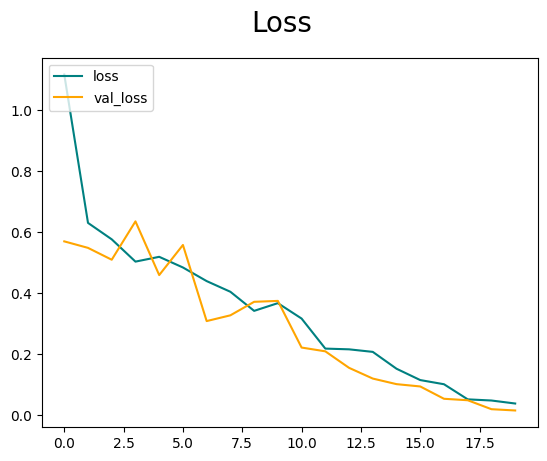

In [40]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

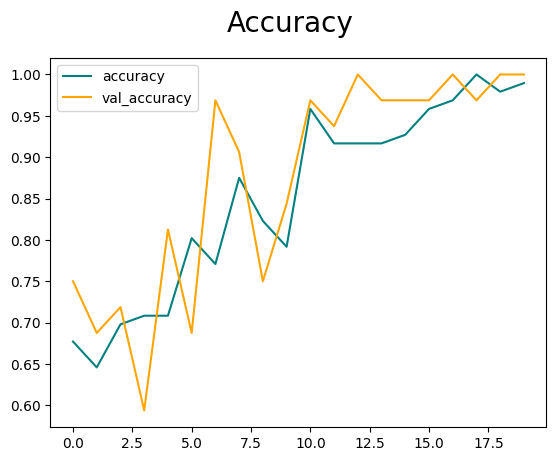

In [41]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Evaluate

In [42]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [43]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [44]:
len(test)

0

In [45]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

In [46]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32)


# Test 

In [72]:

import cv2

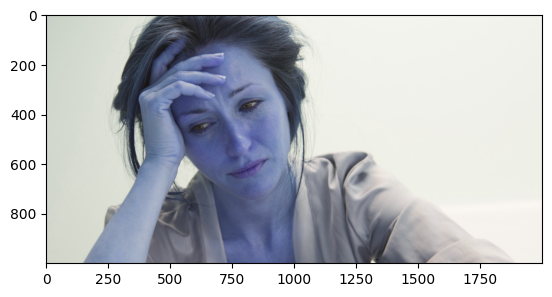

In [73]:
img = cv2.imread('sad-test2.jpeg')
plt.imshow(img)
plt.show()

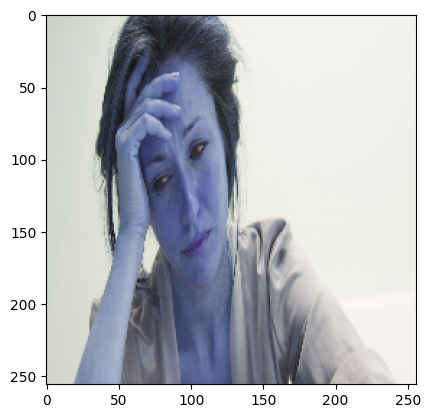

In [74]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [75]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


In [ ]:
print("The emotion is: ")
if(yhat < 0.5):
    print("Happy")
else:
    print("Sad")

The emotion is: 
Happy


# Saving Model